# Chapter 7: Cross-Validation in Finance

**AFML Ch. 7** -- Purged K-Fold cross-validation with embargo.

Standard K-Fold CV leaks information when labels overlap in time. Purged K-Fold
removes training samples whose labels overlap with the test set, and the embargo
further excludes samples immediately after the test set.

This notebook demonstrates:

- PurgedKFold splitter with purging and embargo
- `cv_score` with a custom classifier
- Comparison of purged vs unpurged CV
- Embargo sensitivity analysis

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pymlfinance

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 15
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['axes.labelsize'] = 15
plt.rcParams['xtick.labelsize'] = 13
plt.rcParams['ytick.labelsize'] = 13
plt.rcParams['legend.fontsize'] = 13

np.random.seed(42)

## Generate Synthetic Classification Data

We create a dataset with known informative, redundant, and noise features,
along with overlapping event windows (entry, exit) that simulate financial
labels with temporal dependence.

In [ ]:
n_samples = 200
n_features = 5

# Create features with some signal
X, y = pymlfinance.modeling.make_classification(
    n_samples=n_samples,
    n_informative=3,
    n_redundant=1,
    n_noise=1,
    seed=42
)
print(f"Synthetic dataset: {n_samples} samples, {n_features} features")
print(f"  Label distribution: {np.sum(y == -1)} negative, {np.sum(y == 1)} positive")

In [ ]:
# Create overlapping events (entry, exit)
entries = np.arange(n_samples)
durations = np.random.randint(5, 20, n_samples)
events = [(int(e), min(int(e + d), n_samples - 1)) for e, d in zip(entries, durations)]

## PurgedKFold Splits

PurgedKFold removes from the training set any sample whose event window overlaps
with the test set. The embargo parameter further removes a percentage of samples
immediately after the test period to guard against serial correlation.

In [4]:
pkf = pymlfinance.modeling.PurgedKFold(n_splits=5, embargo_pct=0.02)
folds = pkf.split(events, n_samples)

for i, fold in enumerate(folds):
    train_idx = fold.train
    test_idx = fold.test
    print(f"Fold {i+1}: train={len(train_idx)}, test={len(test_idx)}, "
          f"test_range=[{min(test_idx)}-{max(test_idx)}]")

Fold 1: train=145, test=40, test_range=[0-39]
Fold 2: train=132, test=40, test_range=[40-79]
Fold 3: train=130, test=40, test_range=[80-119]
Fold 4: train=130, test=40, test_range=[120-159]
Fold 5: train=148, test=40, test_range=[160-199]


### Purging Verification

Verifying that no training index overlaps with any test index in each fold.

In [5]:
for i, fold in enumerate(folds):
    train_set = set(fold.train)
    test_set = set(fold.test)
    # Check no overlap
    overlap = train_set & test_set
    print(f"Fold {i+1}: train\u2229test overlap = {len(overlap)} (should be 0)")

Fold 1: train∩test overlap = 0 (should be 0)
Fold 2: train∩test overlap = 0 (should be 0)
Fold 3: train∩test overlap = 0 (should be 0)
Fold 4: train∩test overlap = 0 (should be 0)
Fold 5: train∩test overlap = 0 (should be 0)


### Train/Test Fold Visualization

Each fold is shown as a horizontal bar. Training regions are blue, test regions
are orange, and purged/embargo gaps appear as white space between them.

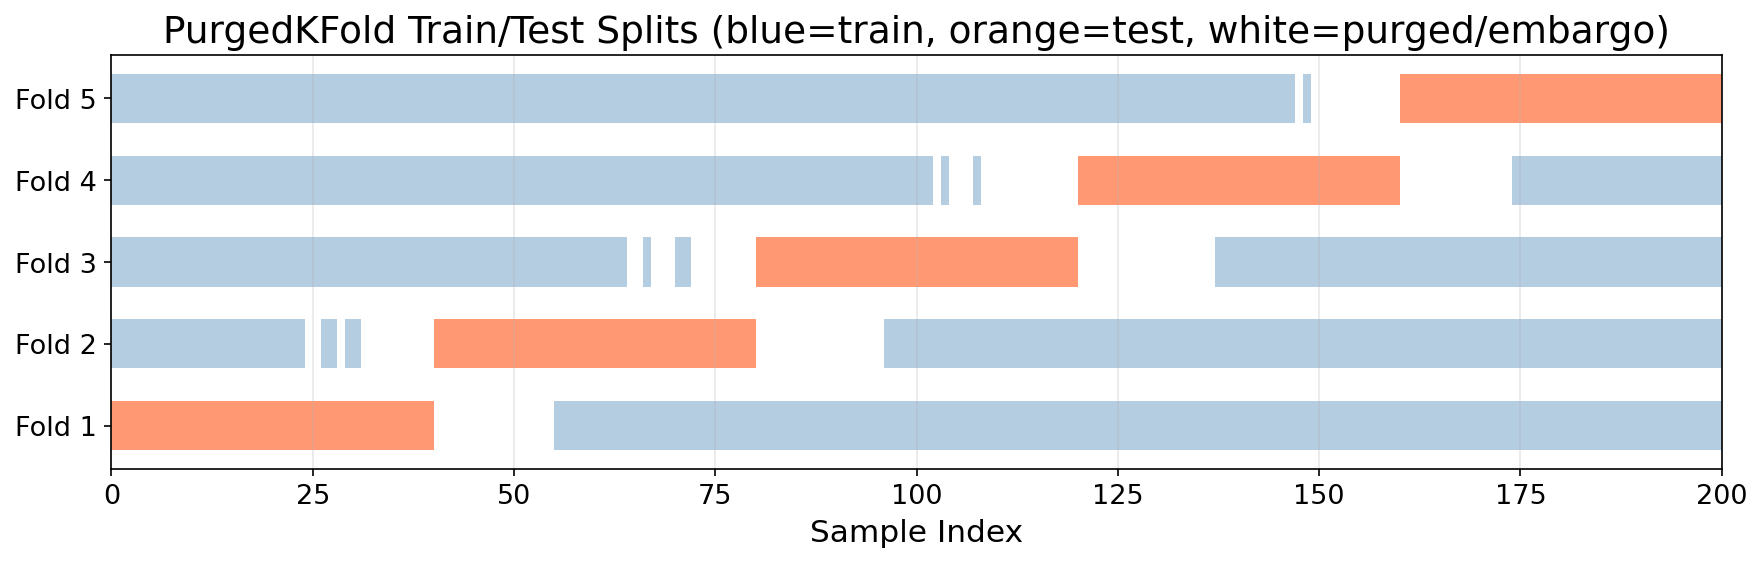

In [6]:
fig, ax = plt.subplots(figsize=(12, 4))

for i, fold in enumerate(folds):
    train_idx = np.array(fold.train)
    test_idx = np.array(fold.test)
    
    # Plot training indices as thin bars
    for idx in train_idx:
        ax.barh(i, 1, left=idx, height=0.6, color='steelblue', alpha=0.4, linewidth=0)
    # Plot test indices as thin bars
    for idx in test_idx:
        ax.barh(i, 1, left=idx, height=0.6, color='coral', alpha=0.8, linewidth=0)

ax.set_yticks(range(len(folds)))
ax.set_yticklabels([f'Fold {i+1}' for i in range(len(folds))])
ax.set_xlabel('Sample Index')
ax.set_title('PurgedKFold Train/Test Splits (blue=train, orange=test, white=purged/embargo)')
ax.set_xlim(0, n_samples)
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## CV Score with Simple Classifier

We create a minimal threshold-based classifier and evaluate it using purged
cross-validation. The classifier uses the mean of the first feature to separate classes.

In [ ]:
class SimpleClassifier:
    """A minimal threshold-based classifier for demonstration."""
    def __init__(self):
        self.threshold = 0.0

    def fit(self, X, y, sample_weight=None):
        # Simple: use the mean of first feature as threshold
        pos_mean = np.mean(X[y == 1, 0]) if np.any(y == 1) else 0
        neg_mean = np.mean(X[y == -1, 0]) if np.any(y == -1) else 0
        self.threshold = (pos_mean + neg_mean) / 2
        return self

    def predict(self, X):
        return np.where(X[:, 0] > self.threshold, 1, -1).astype(np.int32)

In [8]:
clf = SimpleClassifier()
scores = pymlfinance.modeling.cv_score(
    classifier=clf,
    x=X,
    y=y.astype(np.float64),
    events=events,
    n_splits=5,
    embargo_pct=0.02
)
print(f"Per-fold scores: [{', '.join(f'{s:.4f}' for s in scores)}]")
print(f"Mean accuracy:   {np.mean(scores):.4f} +/- {np.std(scores):.4f}")

Per-fold scores: [0.2000, 0.2500, 0.1500, 0.2000, 0.1750]
Mean accuracy:   0.1950 +/- 0.0332


## Embargo Sensitivity Analysis

How does the embargo percentage affect cross-validation scores? Larger embargo
removes more samples near the test boundary, which should reduce information
leakage but also reduce training set size.

In [9]:
embargo_values = [0.0, 0.01, 0.02, 0.05, 0.10]
mean_scores = []
std_scores = []

for embargo in embargo_values:
    clf = SimpleClassifier()
    s = pymlfinance.modeling.cv_score(
        classifier=clf, x=X, y=y.astype(np.float64),
        events=events, n_splits=5, embargo_pct=embargo
    )
    mean_scores.append(np.mean(s))
    std_scores.append(np.std(s))
    print(f"embargo={embargo:.0%}: mean={np.mean(s):.4f} +/- {np.std(s):.4f}")

embargo=0%: mean=0.1950 +/- 0.0332
embargo=1%: mean=0.1950 +/- 0.0332
embargo=2%: mean=0.1950 +/- 0.0332
embargo=5%: mean=0.1950 +/- 0.0332
embargo=10%: mean=0.2000 +/- 0.0354


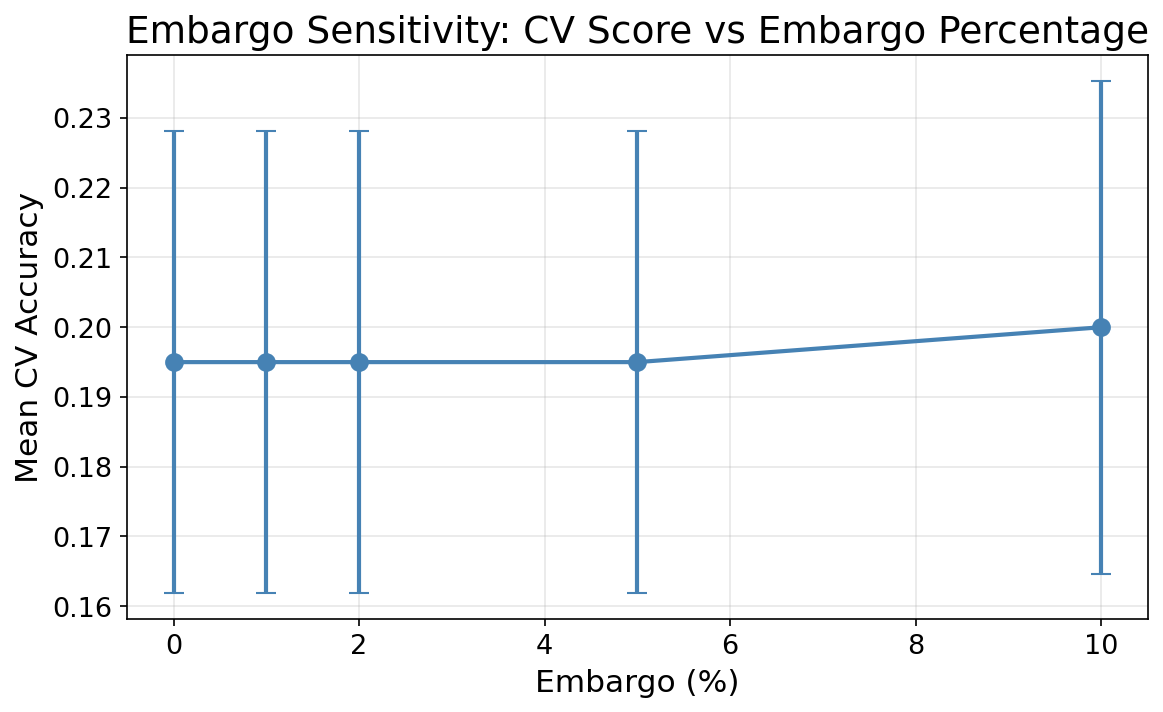

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))

embargo_pcts = [e * 100 for e in embargo_values]
ax.errorbar(embargo_pcts, mean_scores, yerr=std_scores, marker='o',
            capsize=5, linewidth=2, markersize=8, color='steelblue')

ax.set_xlabel('Embargo (%)')
ax.set_ylabel('Mean CV Accuracy')
ax.set_title('Embargo Sensitivity: CV Score vs Embargo Percentage')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Exercises

1. Increase event overlap (longer durations) and observe purging effects
2. Compare 3, 5, and 10 fold CV and how it affects score stability
3. Try a more sophisticated classifier and see if purged CV matters more